# Dependencies

In [41]:
import sys
from pathlib import Path

parent_dir = str(Path().resolve().parent)
parent_dir
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [42]:
%load_ext autoreload
%autoreload 2

from src.dataset import DatasetScraper 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Importing data

In [50]:
scraper = DatasetScraper()
scraper.fetch_database()
scraper.resolve_all_mat_data()

204it [00:00, 4028.83it/s]


In [47]:
scraper.database["mat_url"].isna().sum()/len(scraper.database)

np.float64(0.2107843137254902)

In [51]:
intervention = scraper.database.loc[0]
intervention

fault_diam_in                                                   0.007
motor_load_hp                                                       0
motor_speed_rpm                                                  1797
fault_type                                                      inner
mat_url             https://engineering.case.edu/sites/default/fil...
bearing_position                       12k-fan-end-bearing-fault-data
Name: 0, dtype: object

In [53]:
raw_data = loadmat(scraper.resolve_mat_data(intervention["mat_url"]))

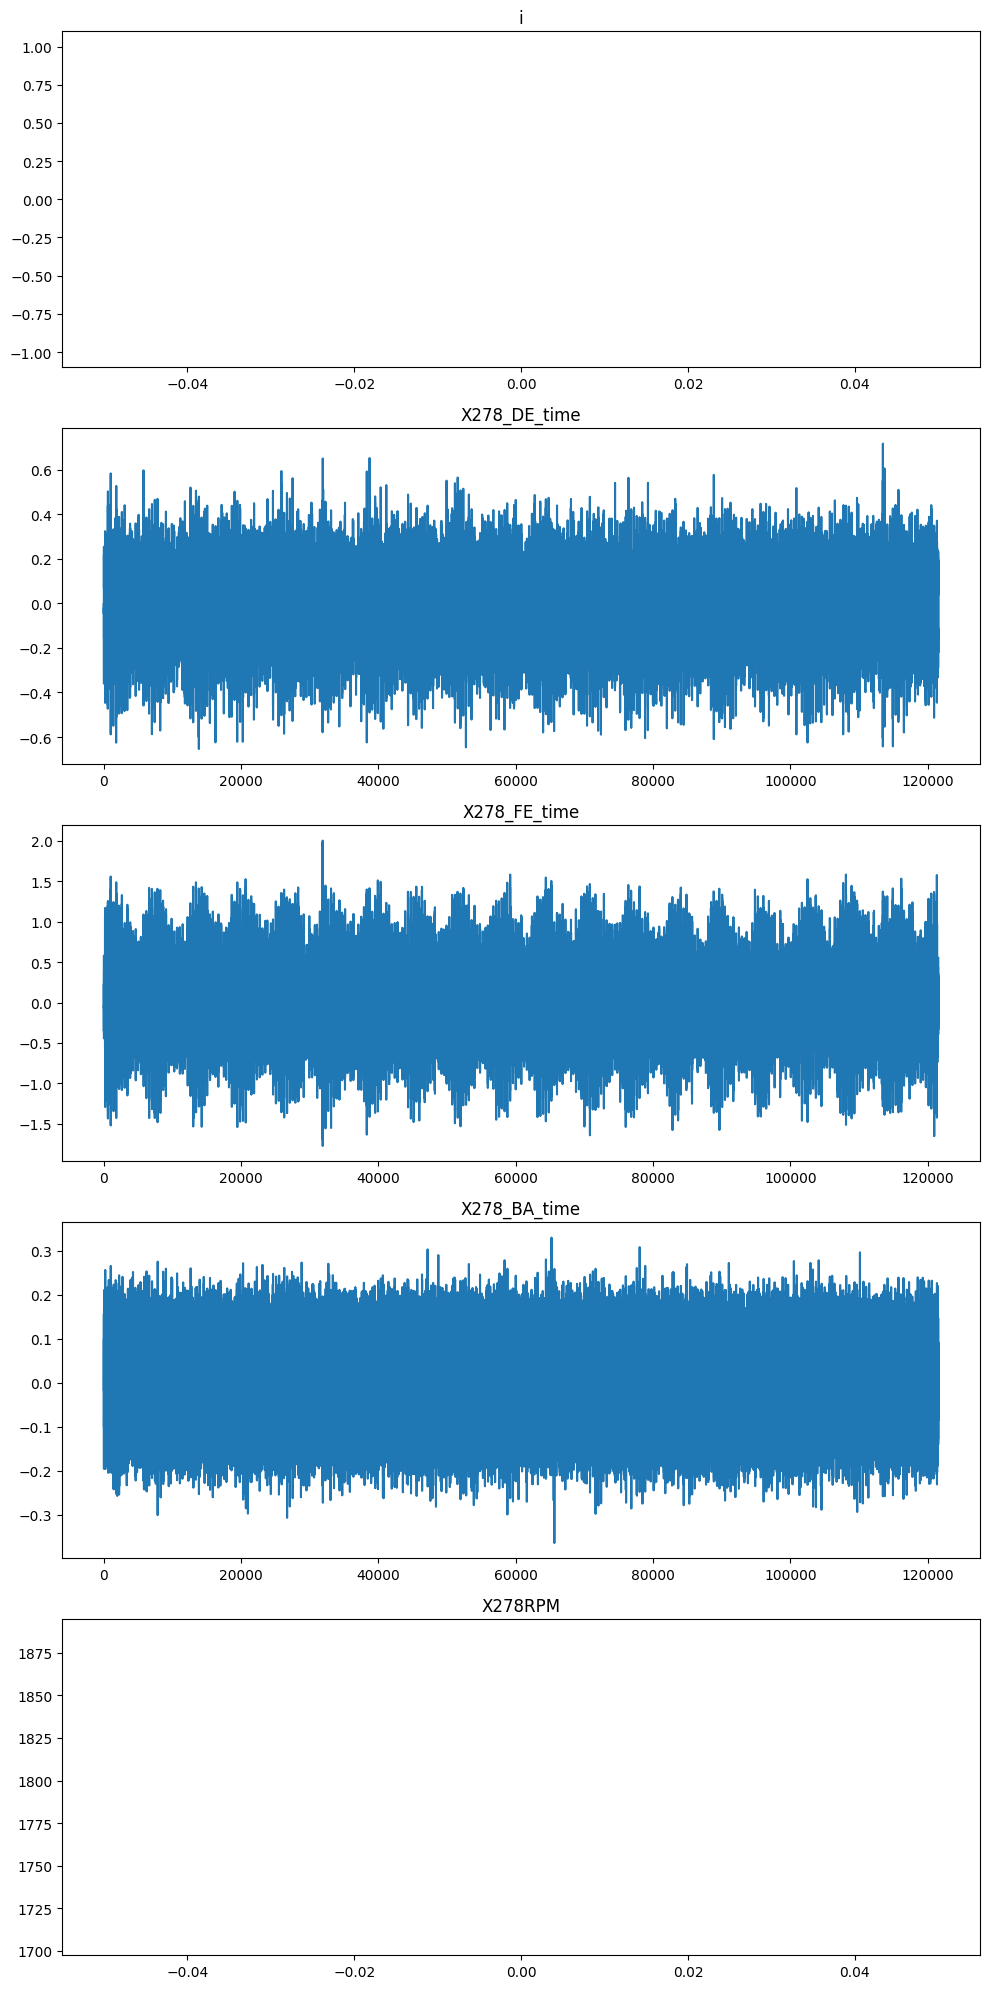

In [54]:
cols = [key for key in raw_data.keys() if not key.startswith("__")]
fig, axs = plt.subplots(len(cols), 1, figsize=(10, 20))
for i, col in enumerate(cols):
    axs[i].plot(raw_data[col])
    axs[i].set_title(col)
plt.tight_layout()
plt.show()